# Seizure detection from EEG data

---

# Preview into dataset

EEG signals have been collected from recordings from 10 different subjects, in total there are 739 EEG recordings (i.e. files). The number of recordings between subjects varies, but each recording is 10 seconds long time window. Recordings are further devided into "seizure" and "nonseizure" subsets. "seizure" subset has 339 EEG signals with seizures. Similarly "non-seizure" subset has 400 records of normal EEG signal. Each record is saved as CSV and has 23 columns that correspond to 23 unique EEG channels. The filename includes the event number and the subject number. For example, 0 is the event number, and 01 is the subject number in “sample_chb01_0.csv.” Note that the subjects have both the “nonseizure” and “seizure” events.

### Overview
- **Total recordings:** 739
- **Subjects:** 10
- **Recording duration:** 10 seconds each
- **File format:** CSV with 23 columns (EEG channels)

## Subsets
| Subset | Count | Description |
|---|---|---|
| Seizure | 339 | EEG recordings with seizure events |
| Non-seizure | 400 | Normal EEG recordings |
| **Total** | **739** | |

### Hierarchy
```
EEG Dataset (739 recordings · 10 subjects)
│
├── Subject 01
│   ├── Seizure recordings
│   └── Non-seizure recordings
│
├── Subject 02
│   ├── Seizure recordings
│   └── Non-seizure recordings
│
├── · · ·
│
└── Subject 10
    ├── Seizure recordings
    └── Non-seizure recordings
```

### Recording (CSV File)
- **Duration:** 10-second time window
- **Columns:** 23 (one per EEG channel)
- **Filename format:** `sample_chb[subj]_[event].csv`
- **Example:** `sample_chb01_0.csv` → subject `01`, event `0`

<div>
    <img src="seizure-node-locations.png">
</div>

---

# Setup 

In [28]:
import os
from collections import defaultdict
import pandas as pd
import numpy as np 
import glob
from pprint import pp

import matplotlib.pyplot as plt
import seaborn as sns


In [29]:
seizure = defaultdict(list)
nonseizure = defaultdict(list)

seizure_data = glob.glob("data/seizure/*.csv")
nonseizure_data = glob.glob("data/nonseizure/*.csv")


In [30]:
def getdata(path, dictionary):
    for file in path:
        df = pd.read_csv(file)
        dictionary[file].append(df)

getdata(seizure_data, seizure)
getdata(nonseizure_data, nonseizure)

seizure_keys = seizure.keys()
nonseizure_keys = nonseizure.keys()
display(seizure)

defaultdict(list,
            {'data/seizure/sample_chb10_6.csv': [          FP1-F7       F7-T7       T7-P7       P7-O1      FP1-F3       F3-C3  \
              0    -116.336996 -158.534799  630.915751  361.318681 -132.161172  153.846154   
              1    -118.681319 -167.326007  650.842491  343.150183 -105.787546  122.197802   
              2    -142.710623  -79.413919  561.758242  288.058608  -85.860806   80.000000   
              3    -123.369963 -134.505495  575.238095  230.036630  -74.725275   16.117216   
              4    -130.989011  -53.626374  494.358974  142.710623  -67.692308  -23.150183   
              ...          ...         ...         ...         ...         ...         ...   
              2555  227.692308 -100.512821 -486.739927  365.421245   55.970696  477.362637   
              2556  232.967033 -212.454212 -435.750916  410.549451   66.520147  453.919414   
              2557  194.285714 -276.336996 -421.098901  456.849817   77.655678  345.494505   
       

In [31]:
for i, path in enumerate(nonseizure.keys()):
    print(f"{i+1}. {path}")

1. data/nonseizure/sample_chb09_30.csv
2. data/nonseizure/sample_chb09_24.csv
3. data/nonseizure/sample_chb10_6.csv
4. data/nonseizure/sample_chb07_21.csv
5. data/nonseizure/sample_chb07_35.csv
6. data/nonseizure/sample_chb09_18.csv
7. data/nonseizure/sample_chb10_11.csv
8. data/nonseizure/sample_chb10_39.csv
9. data/nonseizure/sample_chb09_7.csv
10. data/nonseizure/sample_chb07_8.csv
11. data/nonseizure/sample_chb05_18.csv
12. data/nonseizure/sample_chb02_11.csv
13. data/nonseizure/sample_chb05_24.csv
14. data/nonseizure/sample_chb02_39.csv
15. data/nonseizure/sample_chb05_30.csv
16. data/nonseizure/sample_chb02_38.csv
17. data/nonseizure/sample_chb05_31.csv
18. data/nonseizure/sample_chb05_25.csv
19. data/nonseizure/sample_chb05_19.csv
20. data/nonseizure/sample_chb02_10.csv
21. data/nonseizure/sample_chb07_9.csv
22. data/nonseizure/sample_chb09_6.csv
23. data/nonseizure/sample_chb10_38.csv
24. data/nonseizure/sample_chb10_10.csv
25. data/nonseizure/sample_chb09_19.csv
26. data/nonse

# Visualize data

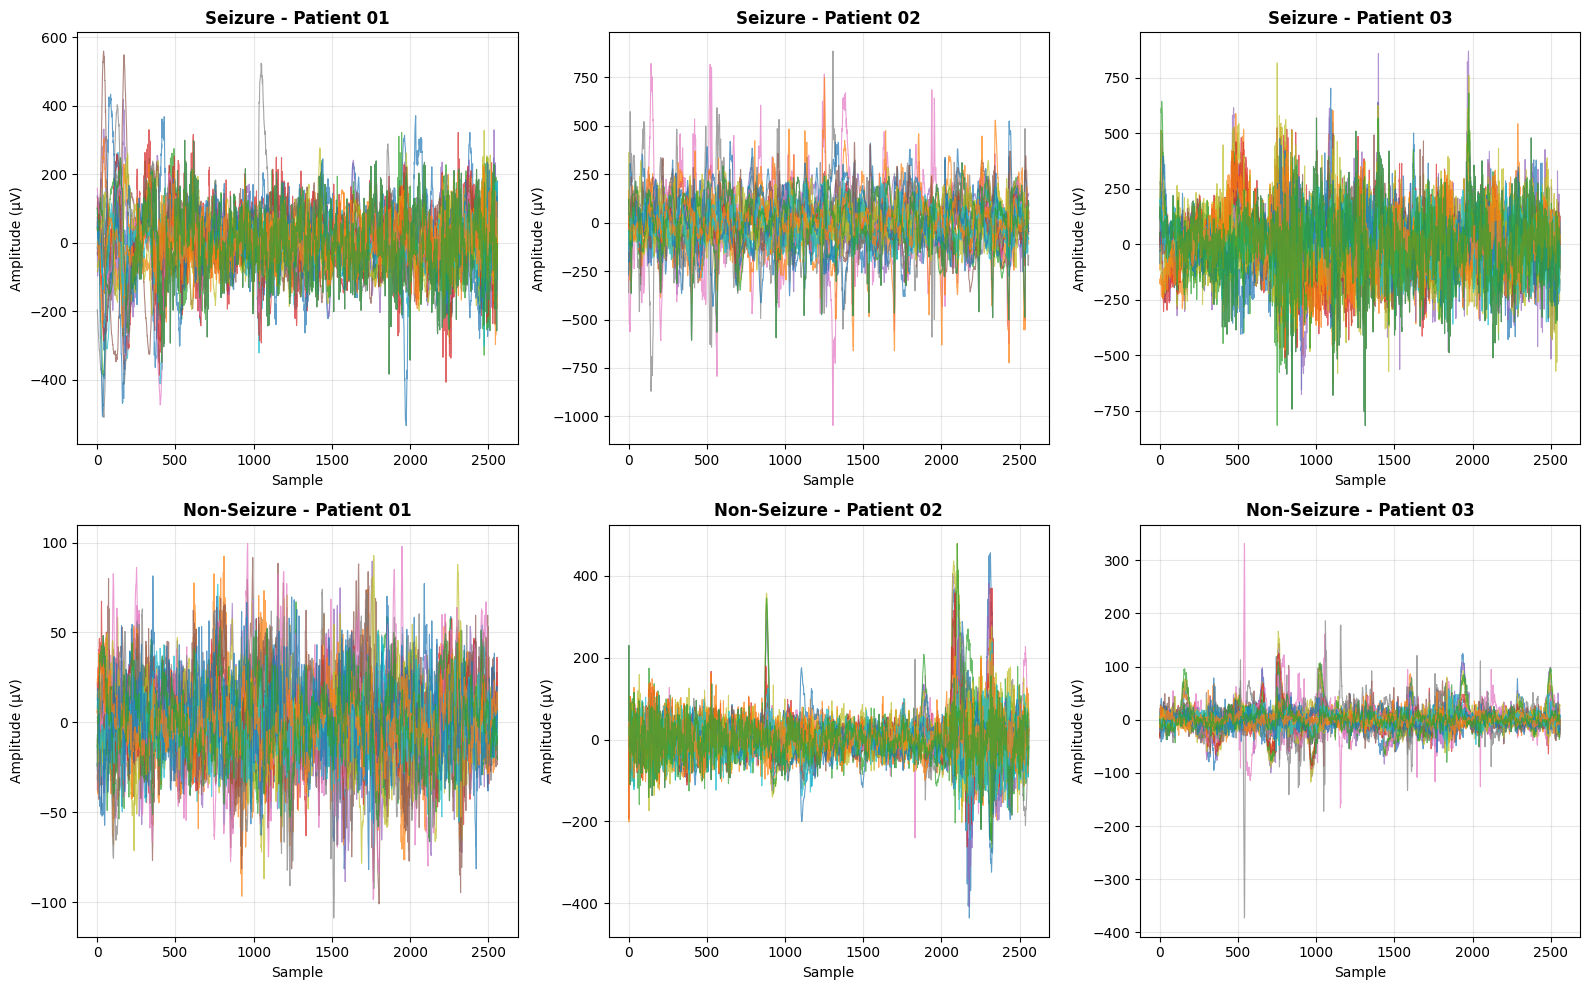

/var/folders/tg/17kz4d950pzg_xjgcw_qbdm00000gn/T/ipykernel_62881/3182864827.py:103: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


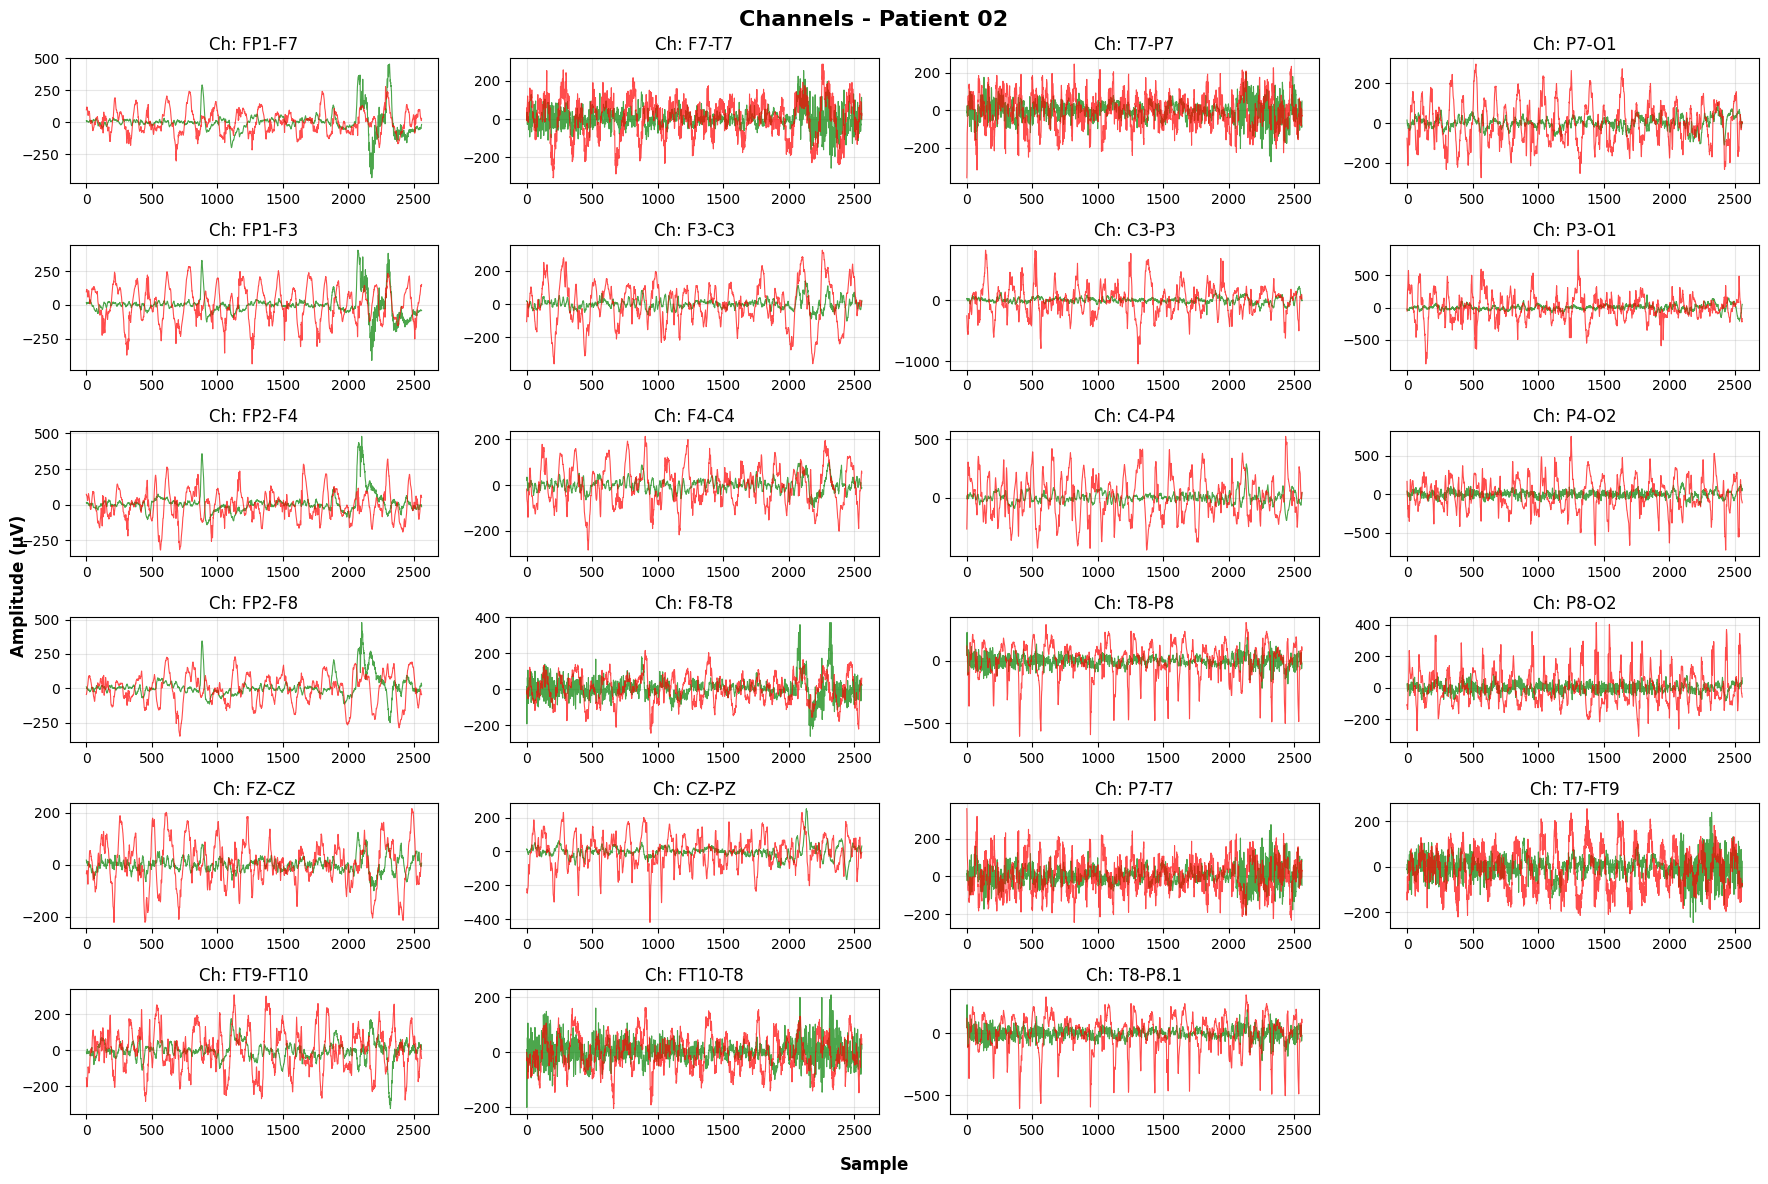

In [ ]:
# Extract patient numbers from file paths
def get_patient_number(filepath):
    """Extract patient number from filepath like 'data/seizure/sample_chb01_0.csv'"""
    filename = filepath.split('/')[-1]  # Get 'sample_chb01_0.csv'
    patient_num = filename.split('chb')[1][:2]  # Extract '01'
    return patient_num

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Get unique patients
seizure_patients = {}
nonseizure_patients = {}

for path in seizure.keys():
    patient = get_patient_number(path)
    if patient not in seizure_patients:
        seizure_patients[patient] = path

for path in nonseizure.keys():
    patient = get_patient_number(path)
    if patient not in nonseizure_patients:
        nonseizure_patients[patient] = path

# Select first 3 patients
selected_patients = sorted(seizure_patients.keys())[:3]

# Plot seizure signals in top row
for idx, patient in enumerate(selected_patients):
    ax = axes[0, idx]
    path = seizure_patients[patient]
    df = seizure[path][0]
    
    # Plot all 23 channels
    for channel in df.columns:
        ax.plot(df[channel], alpha=0.7, linewidth=0.8)
    
    ax.set_title(f'Seizure - Patient {patient}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sample')
    ax.set_ylabel('Amplitude (μV)')
    ax.grid(True, alpha=0.3)

# Plot non-seizure signals in bottom row
for idx, patient in enumerate(selected_patients):
    ax = axes[1, idx]
    path = nonseizure_patients[patient]
    df = nonseizure[path][0]
    
    # Plot all 23 channels
    for channel in df.columns:
        ax.plot(df[channel], alpha=0.7, linewidth=0.8)
    
    ax.set_title(f'Non-Seizure - Patient {patient}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sample')
    ax.set_ylabel('Amplitude (μV)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


def plot_patient_channels(seizure_data, nonseizure_data, patient_num):
    seizure_patients = {}
    nonseizure_patients = {}

    for path in seizure_data.keys():
        patient = get_patient_number(path)
        if patient not in seizure_patients:
            seizure_patients[patient] = path

    for path in nonseizure_data.keys():
        patient = get_patient_number(path)
        if patient not in nonseizure_patients:
            nonseizure_patients[patient] = path
    
    seizure_path = seizure_patients[patient_num]
    nonseizure_path = nonseizure_patients[patient_num]
    seizure_df = seizure_data[seizure_path][0]
    nonseizure_df = nonseizure_data[nonseizure_path][0]

    # Plot channels
    fig, axes = plt.subplots(6, 4, figsize=(18, 12), layout='constrained')
    axes = axes.flatten()

    fig.suptitle(f"Channels - Patient {patient_num}", fontsize=16, fontweight='bold')
    fig.supxlabel('Sample', fontsize=12, fontweight='bold')
    fig.supylabel('Amplitude (μV)', fontsize=12, fontweight='bold')



    # Plot all 23 channels
    for i, (seiz_ch, nonseiz_ch) in enumerate(zip(seizure_df.columns, nonseizure_df.columns)):
        axes[i].plot(nonseizure_df[nonseiz_ch], alpha=0.7, linewidth=0.8, color='green')
        axes[i].plot(seizure_df[seiz_ch], alpha=0.7, linewidth=0.8, color='red')

        axes[i].set_title(f'Ch: {seiz_ch}', fontsize=12)
        axes[i].grid(True, alpha=0.3)

    # remove empty subplot
    fig.delaxes(axes[-1])


    plt.tight_layout()
    plt.show()

plot_patient_channels(seizure, nonseizure, '02')